In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_excel("academic_performance_100.xlsx")
df.head()

,Name,Maths,Science,English,Attendance
0,Student_1,81.0,107.0,35.0,78.0
1,Student_2,44.0,106.0,40.0,98.0
2,Student_3,101.0,46.0,97.0,95.0
3,Student_4,90.0,68.0,NaN,102.0
4,Student_5,50.0,67.0,94.0,80.0


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        100 non-null    object 
 1   Maths       95 non-null     float64
 2   Science     95 non-null     float64
 3   English     95 non-null     float64
 4   Attendance  95 non-null     float64
dtypes: float64(4), object(1)
memory usage: 4.0+ KB


,Maths,Science,English,Attendance
count,95.000000,95.000000,95.000000,95.000000
mean,67.778947,76.115789,61.526316,79.705263
std,24.176734,23.757580,22.192505,15.634028
min,30.000000,35.000000,25.000000,50.000000
25%,44.000000,59.500000,43.500000,69.500000
50%,70.000000,78.000000,59.000000,81.000000
75%,89.000000,96.000000,78.000000,93.000000
max,109.000000,115.000000,104.000000,104.000000


In [7]:
df.isnull().sum()

Name          0
Maths         5
Science       5
English       5
Attendance    5
dtype: int64

In [8]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [9]:
df.isnull().sum()

Name          0
Maths         0
Science       0
English       0
Attendance    0
dtype: int64

In [11]:
for col in ['Maths','Science','English','Attendance']:
    df.loc[df[col] > 100, col] = 100
    df.loc[df[col] < 0, col] = 0

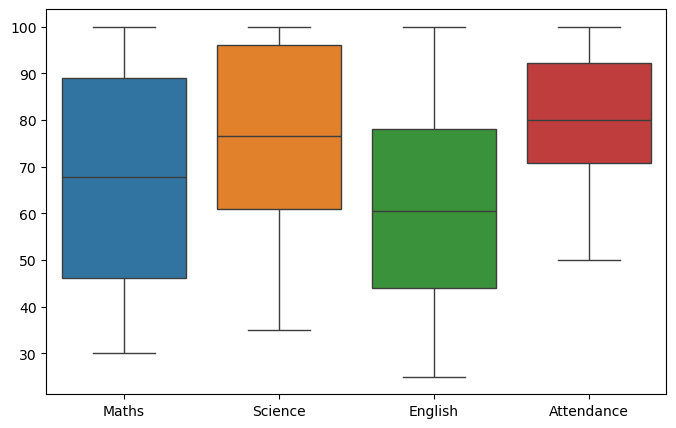

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Maths','Science','English','Attendance']])
plt.show()

In [13]:
Q1 = df[['Maths','Science','English','Attendance']].quantile(0.25)
Q3 = df[['Maths','Science','English','Attendance']].quantile(0.75)
IQR = Q3 - Q1

In [14]:
for col in ['Maths','Science','English','Attendance']:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    
    df[col] = np.where(df[col] > upper, upper,
                       np.where(df[col] < lower, lower, df[col]))

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Maths','Science','English']] = scaler.fit_transform(
    df[['Maths','Science','English']]
)

In [16]:
df['Maths_log'] = np.log(df['Maths'] + 1)

In [17]:
df.head()

,Name,Maths,Science,English,Attendance,Maths_log
0,Student_1,0.728571,1.000000,0.133333,78.0,0.547295
1,Student_2,0.200000,1.000000,0.200000,98.0,0.182322
2,Student_3,1.000000,0.169231,0.960000,95.0,0.693147
3,Student_4,0.857143,0.507692,0.487018,100.0,0.619039
4,Student_5,0.285714,0.492308,0.920000,80.0,0.251314
